# Image reconstruction in X-ray tomography

In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import scipy.io
import matplotlib.pyplot as plt
from scipy.linalg import pinv


## 1. X-ray tomography

### Question 1

In [2]:
# Load data
# Assuming the files are named 'H.mat', 'x.mat', and 'G.mat' and are present in the working directory
H_data = scipy.io.loadmat('data/H.mat')
x_data = scipy.io.loadmat('data/x.mat')

H = H_data['H']  # Projection matrix (sparse)
x = x_data['x']  # Ground truth image

In [3]:
print(x.shape)
print(H.shape)

(8100, 1)
(16200, 8100)


### Question 2

In [4]:
# Step 1: Constructing y with noise
sigma = 1
N = x.shape[0] * x.shape[1]  # Number of pixels
M = H.shape[0]  # Number of measurements

# Generate noise and create measurements
y = H @ x.flatten(order='F') + np.random.normal(0, sigma, M)

### Question 3

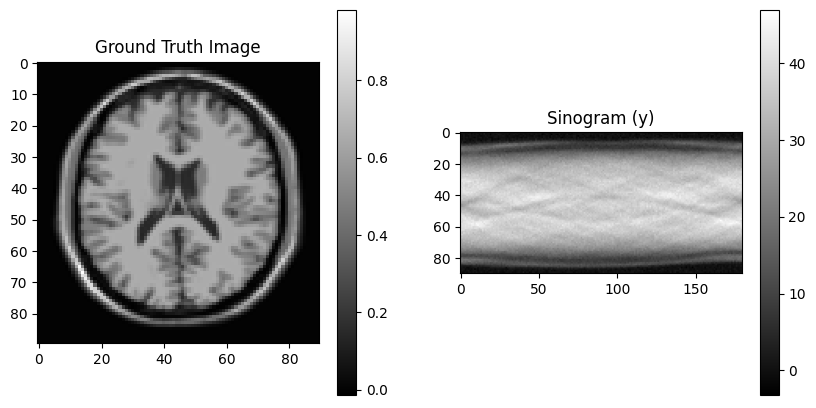

In [5]:
# Reshape x and y for visualization
x_2d = x.reshape((90, 90), order='F')
y_2d = y.reshape((90, 180), order='F')

# Display x and y (sinogram)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title('Ground Truth Image')
plt.imshow(x_2d, cmap='gray')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title('Sinogram (y)')
plt.imshow(y_2d, cmap='gray')
plt.colorbar()

plt.show()


## 2. Optimization problem

### Question 1.

In [6]:
G_data = scipy.io.loadmat('data/G.mat')
G = G_data['G']  # Forward operator (sparse)

### Question 2.

First,
$$
\nabla f(x) = H^T(Hx - y) + \lambda \nabla r(x)
$$

Since
$$
\forall n \in \{1, 2N\}, \quad \big[Cx\big]^{(n)} = \sum_{i=1}^N G_{n,i} x_i
$$
We have, 
$$
\nabla r(x) = \sum_{n=1}^{2N} \sum_{i=1}^N G_{m,i} \psi'\big((Cx)^{(n)}\big) e_i
$$

$$
= \sum_{n=1}^{2N} \psi'\big((Cx)^{(n)}\big) G_n^T
$$
with
$$
\text{et } \forall u \in \mathbb{R}, \quad \psi'(u) = \frac{u / \delta^2}{\sqrt{1 + \frac{u^2}{\delta^2}}}
$$

Thus, 
$$
\nabla \ell(x) = H^T(Hx - y) + \lambda G^T \left(\frac{Gx}{\sqrt{\delta^2 + (Gx)^2}}\right)
$$

In [7]:
lambda_ = 0.13
delta = 0.02

# Gradient of f
def gradient_f(x_flat):
    grad = H.T @ (H @ x_flat - y) + lambda_ * G.T @ (G @ x_flat / np.sqrt(delta**2 + (G @ x_flat)**2  ))
    return grad


### Question 3.

$$
\nabla f(x_1) - \nabla f(x_2) = 
H^T H (x_1 - x_2) 
+ \lambda (\nabla r(x_1) - \nabla r(x_2))
$$

$$
\text{et } \nabla r(x_1) - \nabla r(x_2) = 
\sum_{m=1}^{2N} \left( 
\psi'\big((Cx_1)^{(m)}\big) - \psi'\big((Cx_2)^{(m)}\big) 
\right) G_m^T
$$

$$
\|\psi'(a) - \psi'(b)\| \leq \frac{|a - b|}{\delta^2} 
$$

$$
\text{since } \psi''(u) = \frac{1}{\sqrt{1 + \frac{u^2}{\delta^2}}} - 
\frac{u / \delta^2}{\left( 1 + \frac{u^2}{\delta^2} \right)^{3/2}} 
= \frac{1}{(1 + \frac{u^2}{\delta^2})^{3/2}}
$$

$$
\leq 1
$$

$$
\text{and } \sum_{m=1}^{2N} 
\big[
(Gx_1)^{(m)} - (Gx_2)^{(m)}
\big] G_m^T
\leq \|G\|^2 \|x_1 - x_2\|
$$


In [8]:
# Lipschitz constant
def compute_lipschitz_constant():
    H_norm = spla.svds(H, k=1, return_singular_vectors=False)[0]
    G_norm = spla.svds(G, k=1, return_singular_vectors=False)[0]
    L = H_norm**2 + (lambda_ / delta**2) * G_norm**2
    return L

L = compute_lipschitz_constant()

print(f"Lipschitz constant: {L}")

Lipschitz constant: 18092.77327686487


## 3. Optimization algorithms

## 3.1 Gradient descent algorithm

### Question 1.

In [9]:
# Initial guess
x0 = np.zeros(N)

### Question 2.

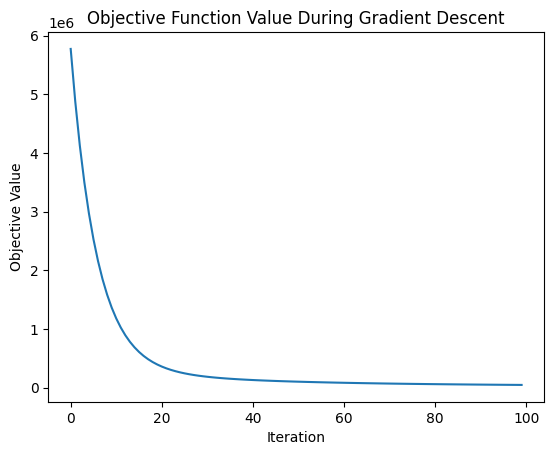

In [10]:
# Gradient Descent Algorithm
def gradient_descent(x0, theta, max_iter=100, tol=1e-4):
    x_k = x0.copy()
    obj_values = []
    for _ in range(max_iter):
        grad = gradient_f(x_k)
        x_k -=theta *  grad / L
        obj_values.append(0.5 * np.linalg.norm(H @ x_k - y)**2 + lambda_ * np.sum(np.sqrt(1 + (G @ x_k)**2 / delta**2)))
        if np.linalg.norm(grad) <= np.sqrt(N) * tol:
            break
    return x_k, obj_values


theta = 1e-1
# Run gradient descent
x_gd, obj_gd = gradient_descent(x0, theta)

# Plot results
plt.figure()
plt.plot(obj_gd)
plt.title("Objective Function Value During Gradient Descent")
plt.xlabel("Iteration")
plt.ylabel("Objective Value")
plt.show()


## 3.2 MM quadratic algorithm

### Question 1.

In [11]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

def curvature_A(x_flat, H, G, lambda_, delta):
    grad_factor = 1 / np.sqrt(1 + (G @ x_flat)**2 / delta**2)
    D_diag = sp.diags(grad_factor.flatten())  # Diagonal matrix
    
    # Create A(x) as a linear operator
    def matvec(v):
        return H.T @ (H @ v) + lambda_ * G.T @ (D_diag @ (G @ v))
    
    def rmatvec(v):
        return matvec(v)  # Symmetric matrix
    
    A_x = spla.LinearOperator(shape=(x_flat.size, x_flat.size), matvec=matvec, rmatvec=rmatvec)
    return A_x


In [12]:
def mm_quadratic(x0, H, G, y, lambda_, delta, theta, max_iter=100, tol=1e-4):
    x_k = x0.copy()
    obj_values = []
    
    for _ in range(max_iter):
        A_xk = curvature_A(x_k, H, G, lambda_, delta)  # Curvature matrix
        grad = gradient_f(x_k)  # Gradient
        
        # Solve A(x_k) * p = grad using bicg (bi-conjugate gradient)
        p_k, _ =  spla.bicg(A_xk, grad, tol=1e-1)
        x_k -= theta *p_k  # Update x
        
        # Compute objective function value
        obj_value = 0.5 * np.linalg.norm(H @ x_k - y)**2 + lambda_ * np.sum(np.sqrt(1 + (G @ x_k)**2 / delta**2))
        obj_values.append(obj_value)
        
        # Convergence check
        if np.linalg.norm(grad) <= tol:
            break
    
    return x_k, obj_values


/var/folders/21/y9qxt5655msd8zr23lpd27_00000gn/T/ipykernel_1976/2067171810.py:10: DeprecationWarning: 'scipy.sparse.linalg.bicg' keyword argument `tol` is deprecated in favor of `rtol` and will be removed in SciPy v1.14.0. Until then, if set, it will override `rtol`.
  p_k, _ =  spla.bicg(A_xk, grad, tol=1e-1)


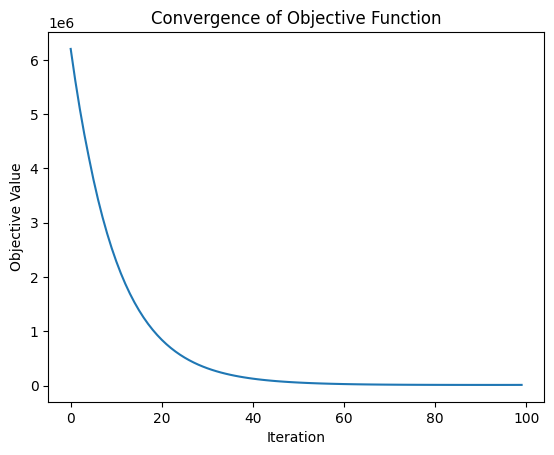

In [13]:
# Example inputs
x0 = np.zeros(H.shape[1])  # Initial guess
lambda_ = 0.13
delta = 0.02
theta = 5e-2

# Run MM Quadratic algorithm
x_mm, obj_mm = mm_quadratic(x0, H, G, y, lambda_, delta, theta)

# Plot convergence
import matplotlib.pyplot as plt
plt.plot(obj_mm)
plt.title("Convergence of Objective Function")
plt.xlabel("Iteration")
plt.ylabel("Objective Value")
plt.show()


### Question 2.

## 3.3 3MG algorithm

### Question 1.

In [14]:
# 3MG Algorithm
def three_mg(x0, max_iter=50, tol=1e-3):
    x_k = x0.copy()
    x_km1 = x0.copy()
    obj_values = []
    for k in range(max_iter):
        D_k = np.column_stack([-gradient_f(x_k), x_k - x_km1]) if k > 0 else -gradient_f(x_k).reshape(-1, 1)
        A_xk = curvature_A(x_k, H, G, lambda_, delta)
        DTD = D_k.T @ A_xk @ D_k
        DTg = D_k.T @ gradient_f(x_k)
        u_k = -np.linalg.pinv(DTD) @ DTg
        x_km1 = x_k.copy()
        x_k += D_k @ u_k
        obj_values.append(0.5 * np.linalg.norm(H @ x_k - y)**2 + lambda_ * np.sum(np.sqrt(1 + (G @ x_k)**2 / delta**2)))
        if np.linalg.norm(gradient_f(x_k)) <= np.sqrt(N) * tol:
            break
    return x_k, obj_values

# Run 3MG algorithm
x_3mg, obj_3mg = three_mg(x0)

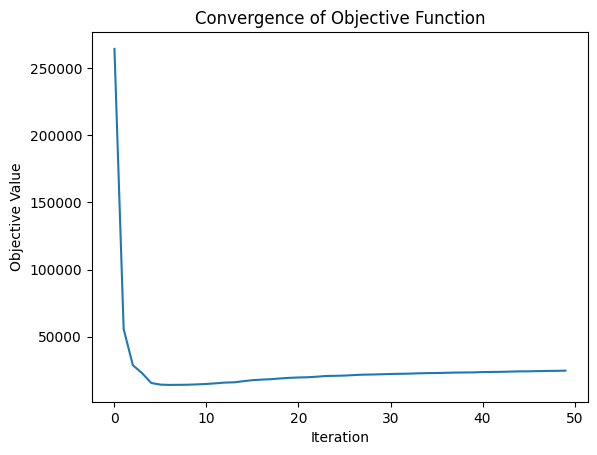

In [15]:
# Plot convergence
import matplotlib.pyplot as plt
plt.plot(obj_3mg)
plt.title("Convergence of Objective Function")
plt.xlabel("Iteration")
plt.ylabel("Objective Value")
plt.show()

## 3.4 Block-coordinate MM quadratic algorithm

### Question 1.

In [16]:
def extract_coordinate(A, block_indices):
    # A is a _CustomLinearOperator
    # block_indices is a list of indices
    # Extract the block of A corresponding to the indices in block_indices
    # Return the block as a numpy array

    block_size = len(block_indices)
    shape = (block_size, block_size)

    def matvec(v):
        full_v = np.zeros(A.shape[1])
        full_v[block_indices] = v
        full_result = A.matvec(full_v)
        return full_result[block_indices]

    def rmatvec(v):
        full_v = np.zeros(A.shape[0])
        full_v[block_indices] = v
        full_result = A.rmatvec(full_v)
        return full_result[block_indices]

    A_block = spla.LinearOperator(shape=shape, matvec=matvec, rmatvec=rmatvec)
    return A_block

In [17]:
A = curvature_A(x0, H, G, lambda_, delta)
A_block = extract_coordinate(A, [0, 1, 2, 3])

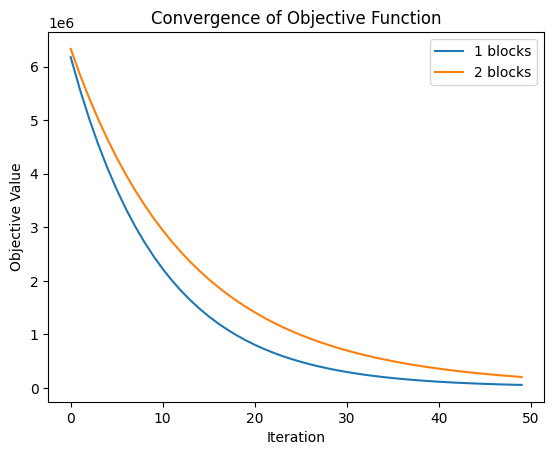

In [ ]:
def block_coordinate_mm(x0, theta, nb_blocks=10, max_iter=50):
    x_k = x0.copy()
    obj_values = []
    block_size = len(x0) // nb_blocks

    for k in range(max_iter):
        j = (k - 1) % nb_blocks + 1  # Cyclic block selection
        block_indices = list(range((j - 1) * block_size, j * block_size))
        A = curvature_A(x_k, H, G, lambda_, delta)
        A_block = extract_coordinate(A, block_indices)
        grad_block = gradient_f(x_k)[block_indices]
        pk, _ = spla.bicg(A_block, grad_block, rtol=1e-2)
        x_k[block_indices] -= theta * pk
        obj_values.append(0.5 * np.linalg.norm(H @ x_k - y)**2 + lambda_ * np.sum(np.sqrt(1 + (G @ x_k)**2 / delta**2)))

    return x_k, obj_values

for K in [1, 2, 3, 5, 6, 9]:
    nb_blocks = K
    theta = 5e-2
    x_bc_mm, obj_bc_mm = block_coordinate_mm(x0, theta, nb_blocks=nb_blocks)
    plt.plot(obj_bc_mm, label=f"{K} blocks")

plt.title("Convergence of Objective Function")
plt.xlabel("Iteration")
plt.ylabel("Objective Value")
plt.legend()
plt.show()



## 3.5 Parallel MM quadratic algorithm

### Question 1.

In [27]:
# Parallel MM Quadratic Algorithm
def parallel_mm(x0, theta, max_iter=5, tol=1e-4):
    x_k = x0.copy()
    obj_values = []
    for _ in range(max_iter):
        print(f"Iteration {_}")
        B_diag = H.T @ H + lambda_ * G.T @ sp.diags(1 / np.sqrt(1 + (G @ x_k)**2 / delta**2)) @ G
        grad = gradient_f(x_k)
        pk, _ =  spla.bicg(B_diag, grad, rtol=1e-1)
        x_k -= theta * pk
        obj_values.append(0.5 * np.linalg.norm(H @ x_k - y)**2 + lambda_ * np.sum(np.sqrt(1 + (G @ x_k)**2 / delta**2)))
        if np.linalg.norm(grad) <= np.sqrt(N) * tol:
            break
    return x_k, obj_values

# Run parallel MM quadratic algorithm
theta = 5e-3
x_par_mm, obj_par_mm = parallel_mm(x0, theta)

Iteration 0
Iteration 1
Iteration 2


KeyboardInterrupt: 

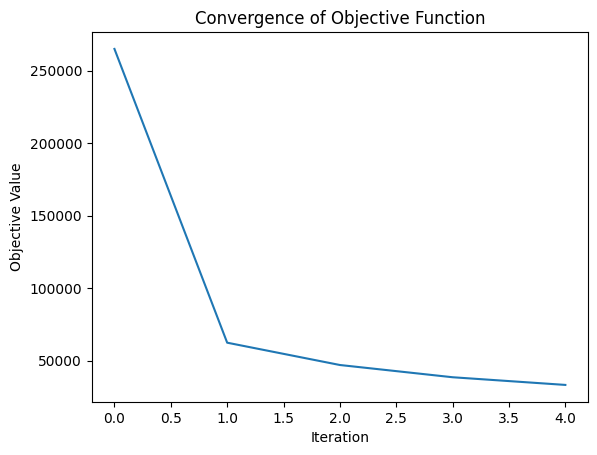

In [34]:
# Plot convergence
import matplotlib.pyplot as plt
plt.plot(obj_par_mm)
plt.title("Convergence of Objective Function")
plt.xlabel("Iteration")
plt.ylabel("Objective Value")
plt.show()

## 3.6 Comparison of the methods

### Question 1.